In [458]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report , precision_score, recall_score, confusion_matrix

In [459]:
df = pd.read_csv('advertising.csv')
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 0:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 1:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 2:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 3:36:18,0


In [460]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Ad Topic Line             1000 non-null   object 
 5   City                      1000 non-null   object 
 6   Male                      1000 non-null   int64  
 7   Country                   1000 non-null   object 
 8   Timestamp                 1000 non-null   object 
 9   Clicked on Ad             1000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 78.3+ KB


In [461]:
df.describe()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,65.000200,36.009000,55000.000080,180.000100,0.481000,0.50000
std,15.853615,8.785562,13414.634022,43.902339,0.499889,0.50025
min,32.600000,19.000000,13996.500000,104.780000,0.000000,0.00000
25%,51.360000,29.000000,47031.802500,138.830000,0.000000,0.00000
50%,68.215000,35.000000,57012.300000,183.130000,0.000000,0.50000
75%,78.547500,42.000000,65470.635000,218.792500,1.000000,1.00000
max,91.430000,61.000000,79484.800000,269.960000,1.000000,1.00000


In [462]:
df.shape

(1000, 10)

In [463]:
df.isnull().sum()

,0
Daily Time Spent on Site,0
Age,0
Area Income,0
Daily Internet Usage,0
Ad Topic Line,0
City,0
Male,0
Country,0
Timestamp,0
Clicked on Ad,0


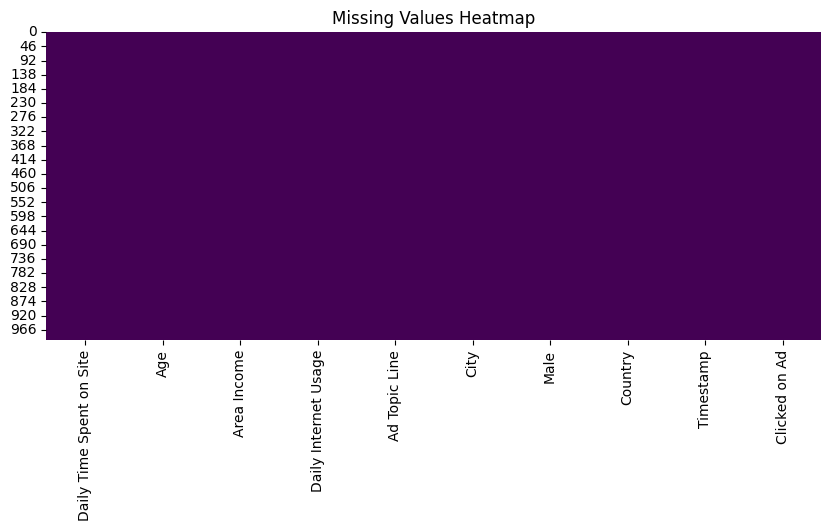

In [464]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.show()

In [465]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Age', ylabel='count'>

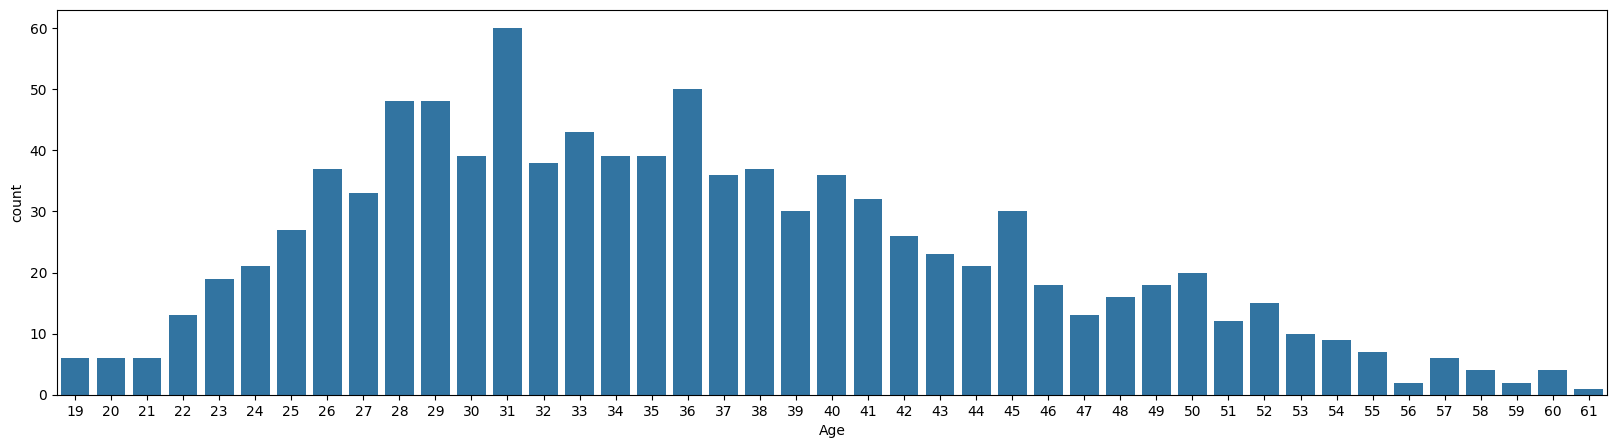

In [466]:
fig = plt.figure(figsize = (20, 5))
sns.countplot(x ='Age', data = df)

Text(0.5, 1.0, 'Ad Click Distribution')

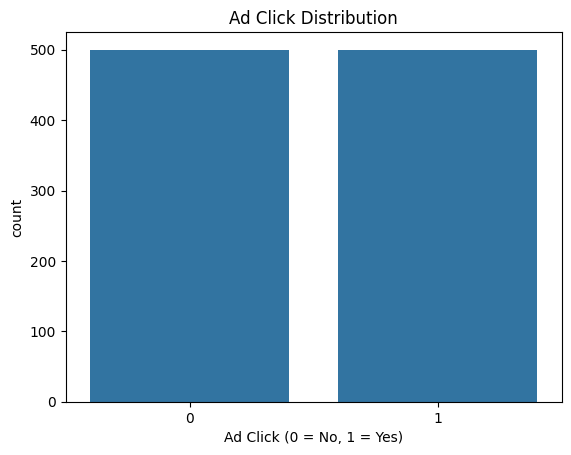

In [467]:
sns.countplot(x='Clicked on Ad', data=df)
plt.xlabel("Ad Click (0 = No, 1 = Yes)")
plt.title("Ad Click Distribution")

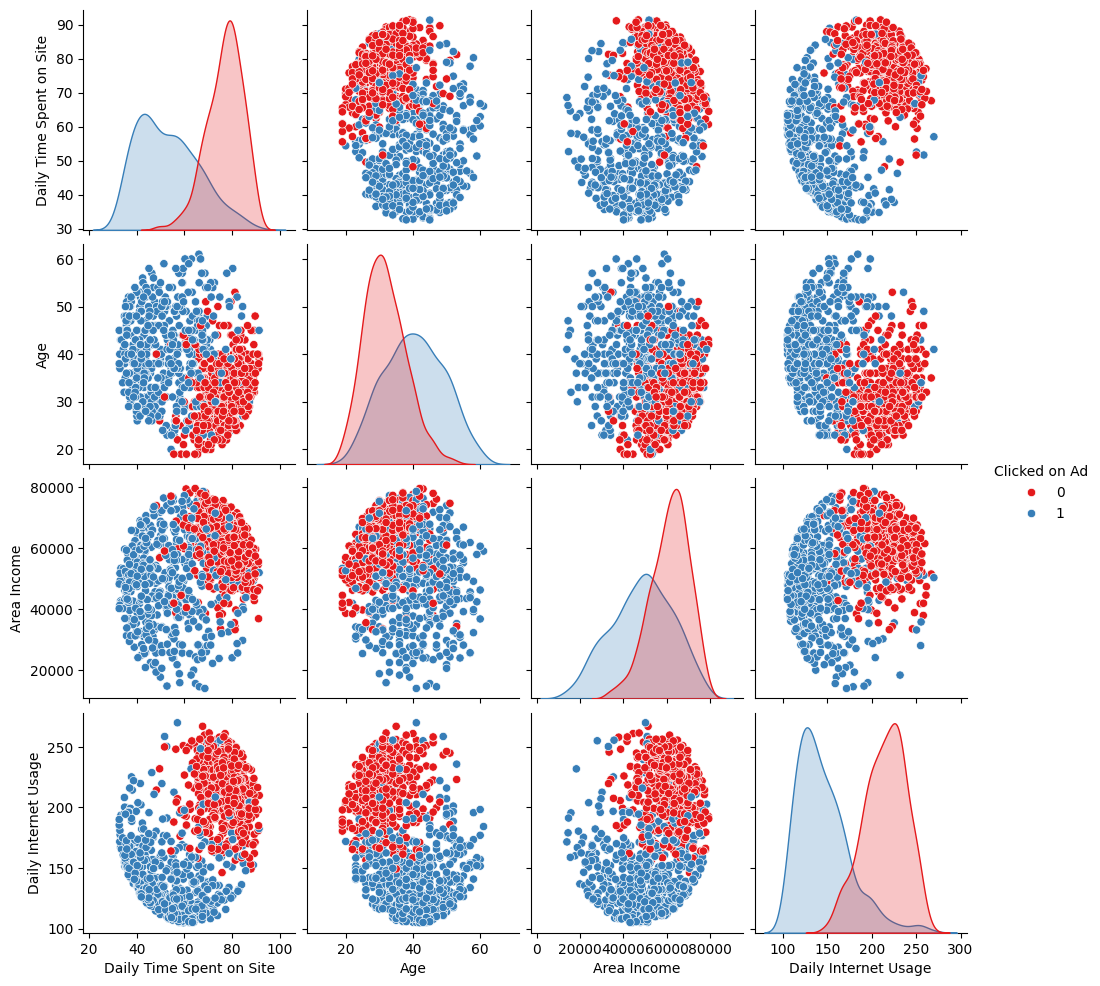

In [468]:
sns.pairplot(df, hue='Clicked on Ad', vars=['Daily Time Spent on Site',
                                            'Age',
                                           'Area Income',
                                           'Daily Internet Usage'], palette='Set1')

<Axes: xlabel='Age', ylabel='Daily Time Spent on Site'>

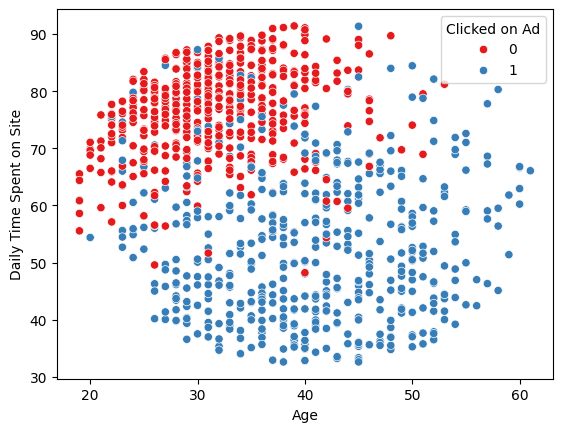

In [469]:
sns.scatterplot(x='Age',y='Daily Time Spent on Site',
                hue='Clicked on Ad', data=df, palette='Set1')

<Axes: xlabel='Area Income', ylabel='Daily Time Spent on Site'>

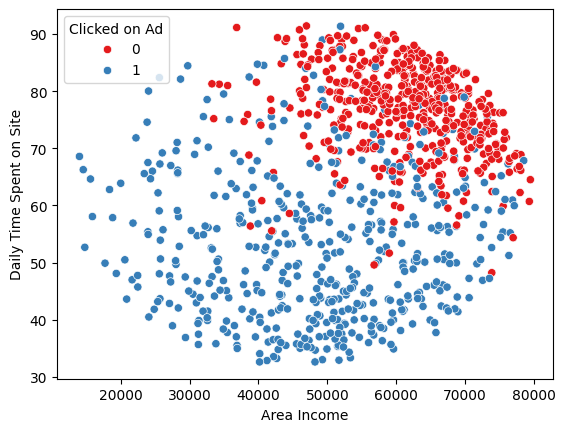

In [470]:
sns.scatterplot(x='Area Income',y='Daily Time Spent on Site',
                hue='Clicked on Ad', data=df, palette='Set1')

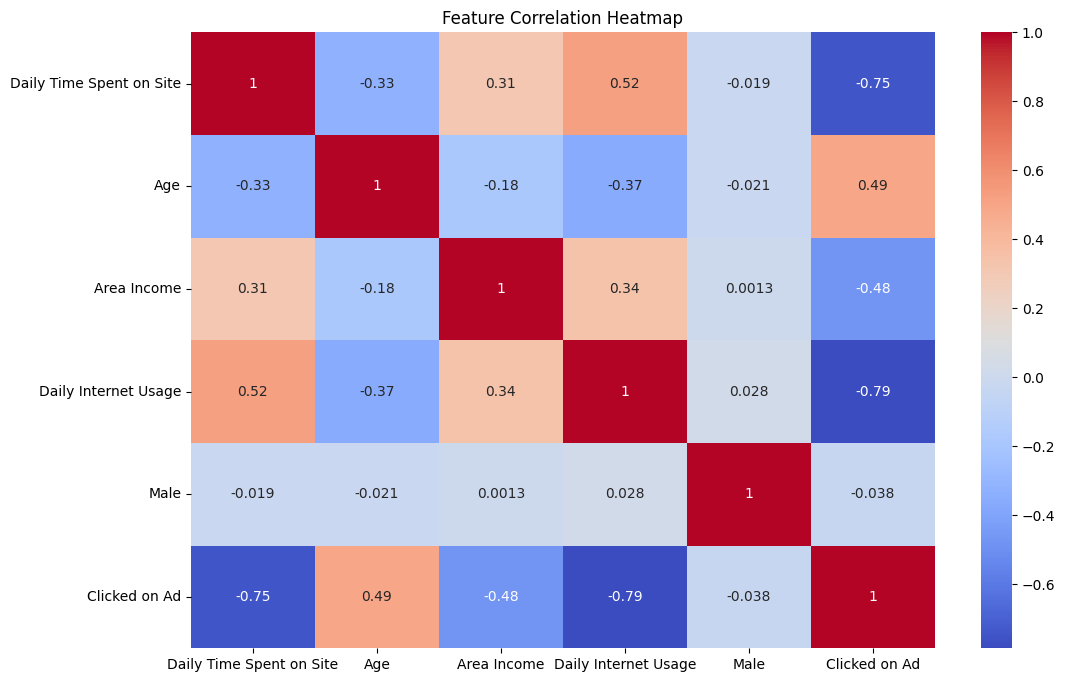

In [471]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

Text(0.5, 1.0, 'Classification Count')

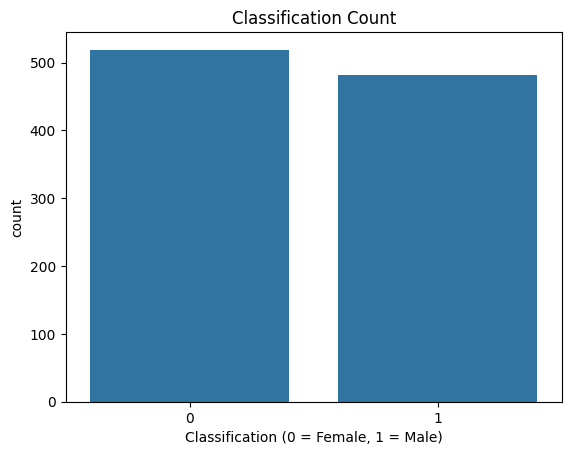

In [472]:
sns.countplot(x='Male', data=df)
plt.xlabel("Classification (0 = Female, 1 = Male)")
plt.title("Classification Count")

In [473]:
country_counts = df['Country'].value_counts()
print(country_counts)

Country
Czech Republic      9
France              9
Senegal             8
Peru                8
Greece              8
                   ..
Kiribati            1
Marshall Islands    1
Bermuda             1
Mozambique          1
Lesotho             1
Name: count, Length: 237, dtype: int64


In [474]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Ad Topic Line,City,Male,Country,Timestamp,Clicked on Ad
0,68.95,35,61833.90,256.09,Cloned 5thgeneration orchestration,Wrightburgh,0,Tunisia,2016-03-27 0:53:11,0
1,80.23,31,68441.85,193.77,Monitored national standardization,West Jodi,1,Nauru,2016-04-04 1:39:02,0
2,69.47,26,59785.94,236.50,Organic bottom-line service-desk,Davidton,0,San Marino,2016-03-13 20:35:42,0
3,74.15,29,54806.18,245.89,Triple-buffered reciprocal time-frame,West Terrifurt,1,Italy,2016-01-10 2:31:19,0
4,68.37,35,73889.99,225.58,Robust logistical utilization,South Manuel,0,Iceland,2016-06-03 3:36:18,0


<Axes: xlabel='Month'>

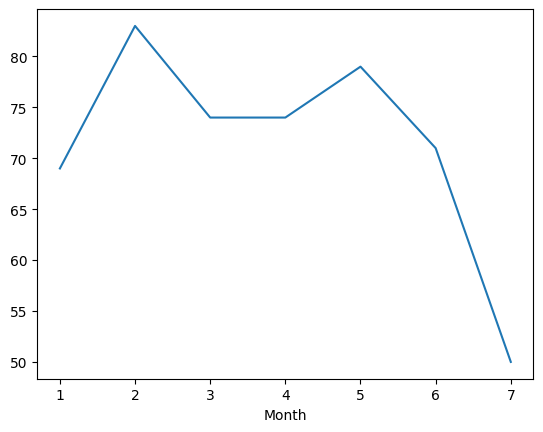

In [475]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Month'] = df['Timestamp'].dt.month

df['Month'][df['Clicked on Ad'] == 1].value_counts().sort_index().plot()

<Axes: xlabel='Day'>

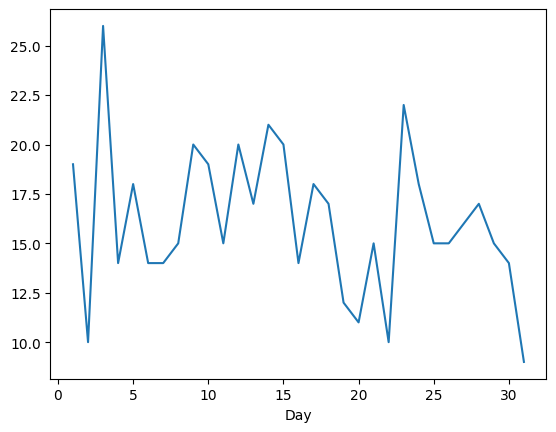

In [476]:
df['Day'] = df['Timestamp'].dt.day
df['Day'][df['Clicked on Ad'] == 1].value_counts().sort_index().plot()

In [477]:
df.drop(["Ad Topic Line","City","Country" , 'Timestamp' , "Day"],axis=1,inplace=True)

In [478]:
df.head()

,Daily Time Spent on Site,Age,Area Income,Daily Internet Usage,Male,Clicked on Ad,Month
0,68.95,35,61833.90,256.09,0,0,3
1,80.23,31,68441.85,193.77,1,0,4
2,69.47,26,59785.94,236.50,0,0,3
3,74.15,29,54806.18,245.89,1,0,1
4,68.37,35,73889.99,225.58,0,0,6


In [479]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Daily Time Spent on Site  1000 non-null   float64
 1   Age                       1000 non-null   int64  
 2   Area Income               1000 non-null   float64
 3   Daily Internet Usage      1000 non-null   float64
 4   Male                      1000 non-null   int64  
 5   Clicked on Ad             1000 non-null   int64  
 6   Month                     1000 non-null   int32  
dtypes: float64(3), int32(1), int64(3)
memory usage: 50.9 KB


In [480]:
X = df.drop(columns=["Clicked on Ad"])
y = df["Clicked on Ad"]

In [481]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [482]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [483]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_pred = log_model.predict(X_test_scaled)

log_acc = accuracy_score(y_test, log_pred)
log_prec = precision_score(y_test, log_pred)
log_rec = recall_score(y_test, log_pred)
log_cm = confusion_matrix(y_test, log_pred)

In [484]:
svm_model = SVC(kernel = 'linear' ,  random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(y_test, svm_pred)
svm_prec = precision_score(y_test, svm_pred)
svm_rec = recall_score(y_test, svm_pred)
svm_cm = confusion_matrix(y_test, svm_pred)

In [485]:
rf_model = RandomForestClassifier(n_estimators= 100 , random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_prec = precision_score(y_test, rf_pred)
rf_rec = recall_score(y_test, rf_pred)
rf_cm = confusion_matrix(y_test, rf_pred)

In [486]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier( eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_prec = precision_score(y_test, xgb_pred)
xgb_rec = recall_score(y_test, xgb_pred)
xgb_cm = confusion_matrix(y_test, xgb_pred)

In [487]:
from sklearn.tree import DecisionTreeClassifier
base_models = [
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True))
]

final_model = LogisticRegression(max_iter=1000)

stack_model = StackingClassifier(
    estimators=base_models,
    final_estimator=final_model,
    cv=5
)

stack_model.fit(X_train, y_train)
stack_pred = stack_model.predict(X_test)

stack_acc = accuracy_score(y_test, stack_pred)
stack_prec = precision_score(y_test, stack_pred)
stack_rec = recall_score(y_test, stack_pred)
stack_cm = confusion_matrix(y_test, stack_pred)

In [488]:
models = ['Logistic Regression', 'SVM', 'Random Forest', 'XGboost' , 'Stacking']
accuracy = [log_acc, svm_acc, rf_acc, xgb_acc ,stack_acc]
precision = [log_prec, svm_prec, rf_prec, xgb_prec , stack_prec]
recall = [log_rec, svm_rec, rf_rec, xgb_rec , stack_rec]
cms = [log_cm, svm_cm, rf_cm, xgb_cm , stack_cm]
data = {
    'Precision': precision,
    'Recall': recall,
    'Accuracy': accuracy,
    'Confusion Matrix': cms,
}

df = pd.DataFrame(data, index=models)
df

,Precision,Recall,Accuracy,Confusion Matrix
Logistic Regression,0.972477,0.954955,0.960,"[[86, 3], [5, 106]]"
SVM,0.972477,0.954955,0.960,"[[86, 3], [5, 106]]"
Random Forest,0.962617,0.927928,0.940,"[[85, 4], [8, 103]]"
XGboost,0.928571,0.936937,0.925,"[[81, 8], [7, 104]]"
Stacking,0.936937,0.936937,0.930,"[[82, 7], [7, 104]]"


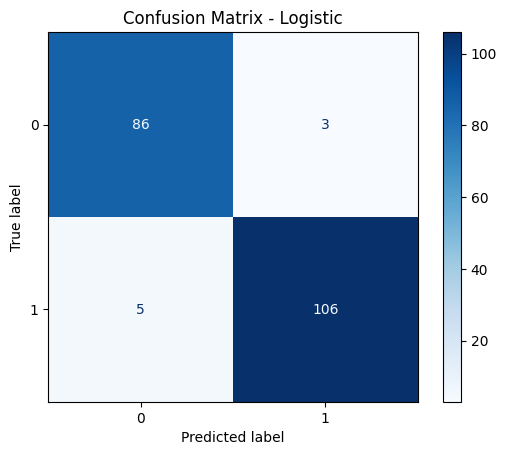

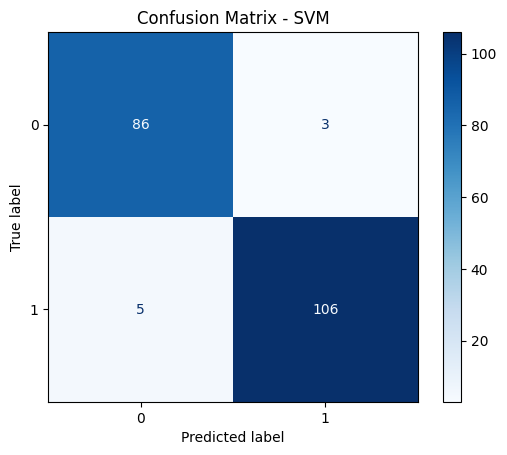

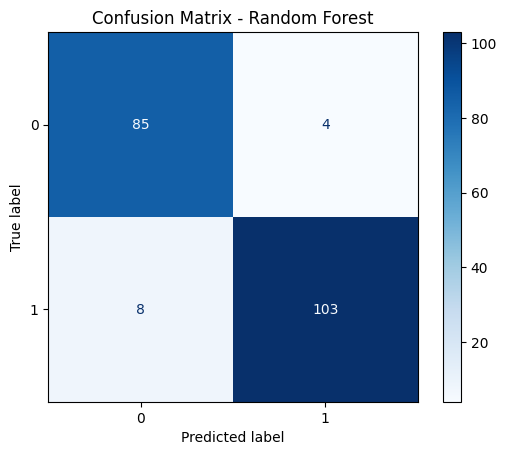

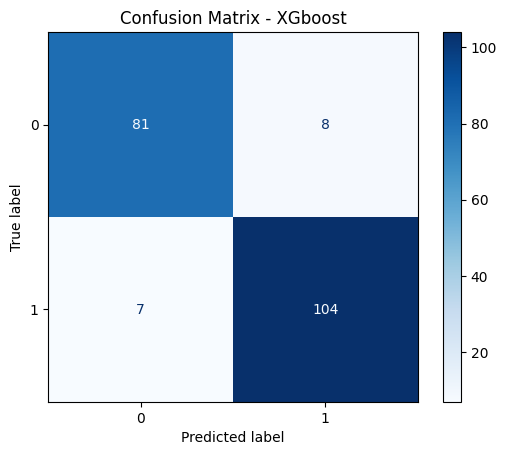

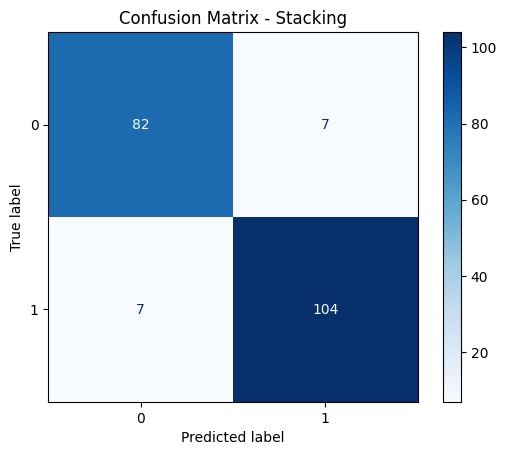

In [489]:
disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Logistic")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm, display_labels=svm_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - SVM")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm, display_labels=rf_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Random Forest")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=xgb_cm, display_labels=xgb_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - XGboost")
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=stack_cm, display_labels=stack_model.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Stacking")
plt.show()

In [490]:
best_accuracy = 0
best_model_name = ""

for i in range(len(models)):
    if accuracy[i] > best_accuracy:
        best_accuracy = accuracy[i]
        best_model_name = models[i]

print("Best model based on accuracy:", best_model_name)
print("Accuracy:", best_accuracy)


Best model based on accuracy: Logistic Regression
Accuracy: 0.96
